In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Sampling setup
fs = 100
N = 100
t = np.arange(N) / fs

# Two sine waves
x_30 = np.sin(2 * np.pi * 30 * t)
x_70 = np.sin(2 * np.pi * 70 * t)

In [ ]:
# Manual DFT implementation (no np.fft)
def manual_dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        s = 0j
        for n in range(N):
            angle = (-2j * np.pi * k * n) / N
            s += x[n] * np.exp(angle)
        X[k] = s
    return X

In [4]:
# Manual frequency bins (equivalent to fftfreq)
def manual_fftfreq(N, fs):
    freq = np.zeros(N)
    for k in range(N):
        if k <= N // 2:
            freq[k] = k * fs / N
        else:
            freq[k] = (k - N) * fs / N
    return freq

In [5]:
# Manual argmax
def manual_argmax(arr):
    max_idx = 0
    for i in range(1, len(arr)):
        if arr[i] > arr[max_idx]:
            max_idx = i
    return max_idx


In [6]:
# DFT (one-sided magnitude spectrum) using manual implementation
freq = manual_fftfreq(N, fs)

X30 = manual_dft(x_30)
X70 = manual_dft(x_70)

mag30 = np.abs(X30) / N
mag70 = np.abs(X70) / N

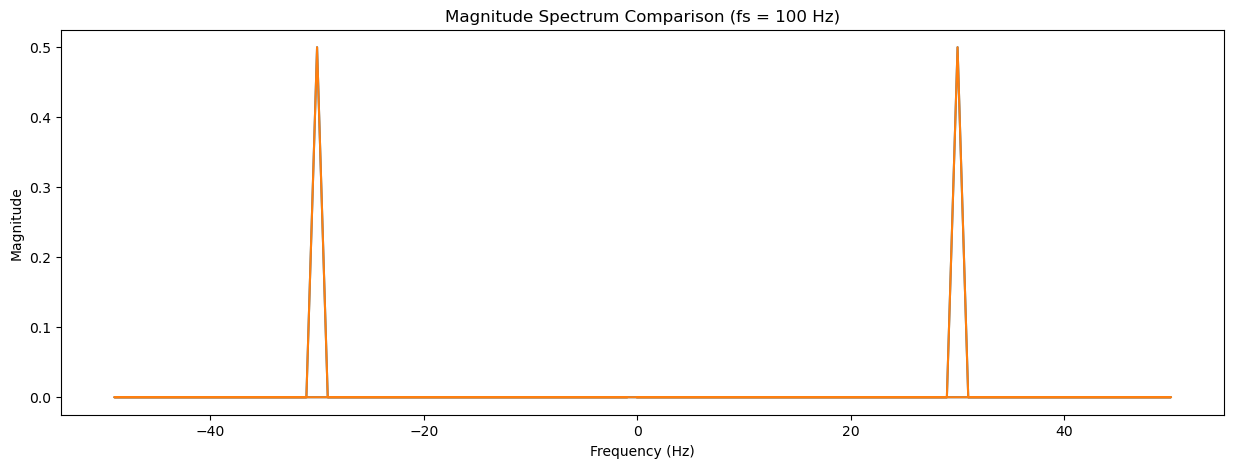

In [7]:
# Plot spectra
plt.figure(figsize=(15, 5))
plt.plot(freq, mag30)
plt.plot(freq, mag70)
plt.title('Magnitude Spectrum Comparison (fs = 100 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()

In [8]:
# Print peak frequencies using manual argmax
peak30 = freq[manual_argmax(mag30)]
peak70 = freq[manual_argmax(mag70)]
print(f'Peak for 30 Hz sine: {peak30:.1f} Hz')
print(f'Peak for 70 Hz sine: {peak70:.1f} Hz')

Peak for 30 Hz sine: -30.0 Hz
Peak for 70 Hz sine: -30.0 Hz


In [9]:
# DFT (one-sided magnitude spectrum)
freq = np.fft.fftfreq(N, d=1/fs)

X30 = np.fft.fft(x_30)
X70 = np.fft.fft(x_70)

mag30 = np.abs(X30) / N
mag70 = np.abs(X70) / N